## Global variables

You must manually set two variables:
- `save_dir`: Where the figures will be saved
- `figures_data_dir`: The absolute path to `idp-design/figures/data/`

In [1]:
from datetime import date
from pathlib import Path

save_dir = 'Output' # Output folder in current directory
assert(Path(save_dir)).exists()

figures_data_dir = 'Data' # FIXME (keep the trailing "/"!)
assert(Path(figures_data_dir)).exists()

## Libraries

In [2]:
import matplotlib
mpl = matplotlib

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

mpl.rcParams['figure.figsize'] = (6.0,4.0) # default = (6.0, 4.0)
mpl.rcParams['font.size']      = 12       # default = 10

mpl.rcParams['axes.linewidth']    = 0.75 # default = 1.0
mpl.rcParams['lines.linewidth']   = 1.5 # default = 1.0
mpl.rcParams['patch.linewidth']   = 1.0 # default = 1.0
mpl.rcParams['grid.linewidth']    = 0.5 # default = 0.5
mpl.rcParams['xtick.major.width'] = 1.0 # default = 0.5
mpl.rcParams['xtick.minor.width'] = 0.0 # default = 0.5
mpl.rcParams['ytick.major.width'] = 1.0 # default = 0.5
mpl.rcParams['ytick.minor.width'] = 0.0 # default = 0.5

def make_nice_axis(ax):
    """ Function to beautify axis"""
    ax.xaxis.set_ticks_position('bottom')
    ax.xaxis.set_tick_params(pad=10,top='on',direction='in')
    ax.yaxis.set_tick_params(pad=10,top='on',direction='in')
    ax.xaxis.set_tick_params(labelsize=10)
    ax.yaxis.set_tick_params(labelsize=10)

import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
plt.rc('font', family='Arial')
import pandas as pd
import os

def save_figure(fig, fig_file):
    """
    Save the given figure object as PDF and PNG formats.

    Parameters:
    fig (matplotlib.figure.Figure): The figure object to be saved.
    fig_file (str): The file path (including the file name without extension) where the figure will be saved.

    Returns:
    None
    """
    os.makedirs(os.path.dirname(fig_file), exist_ok=True)
    fig.savefig(fname=fig_file + ".pdf", dpi=300, format='pdf', bbox_inches='tight')
    fig.savefig(fname=fig_file + ".png", dpi=1200, format='png', bbox_inches='tight')

### Main Figures ###

### Fig 1B(Dimer and Finches model) ###

In [7]:
path_to_fig1b_data = figures_data_dir + '/Fig1/data/'
fig1b_data_dimer = pd.read_csv(path_to_fig1b_data + 'Fig_1b_Dimer.csv')
fig1b_data_finches = pd.read_csv(path_to_fig1b_data + 'Fig_1b_Finches.csv')

Output/fig1/chi_vs_rg_dimer


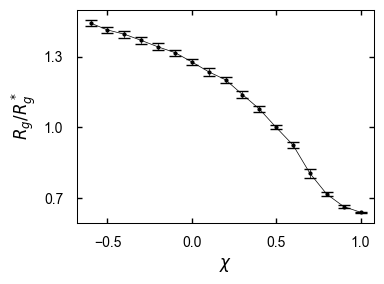

In [4]:
fig, ax = plt.subplots(1,1,figsize=(4,3))
make_nice_axis(ax)

# Calculate standard deviation across replicates for each chi value
std_values = fig1b_data_dimer.iloc[:,1:-1].T.std()

# Plot with error bars
avg_Rg_at_chi_05 = fig1b_data_dimer.loc[fig1b_data_dimer['chi'] == 0.5,  'avg'].values[0]
ax.errorbar(fig1b_data_dimer['chi'], fig1b_data_dimer['avg']/avg_Rg_at_chi_05, yerr=std_values/avg_Rg_at_chi_05, 
            fmt='o-', capsize=4, lw=0.5, color='k', ecolor='k', markersize=2)
ax.set_yticks([0.7, 1.0, 1.3])
ax.set_xlabel('$\\chi$')
ax.set_ylabel('$R_g/R_g^*$')
plt.tight_layout()
fig_save = True
fig_name = 'fig1/chi_vs_rg_dimer'
if fig_save:
    print(save_dir + '/' + fig_name)
    save_figure(fig, fig_file=save_dir+'/'+fig_name)
plt.show()

Output/fig1/epsilon_vs_rg_finches


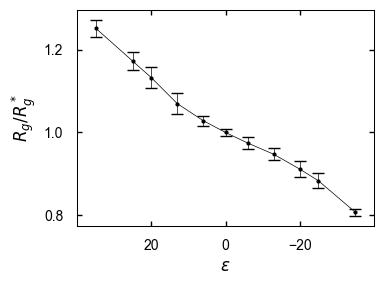

In [8]:
fig, ax = plt.subplots(1,1,figsize=(4,3))
make_nice_axis(ax)

# Calculate standard deviation across replicates for each epsilon value
std_values = fig1b_data_finches.iloc[:,1:-1].T.std()

# Plot with error bars (normalized by value at epsilon = 0)
avg_Rg_at_eps_0 = fig1b_data_finches.loc[fig1b_data_finches['epsilon'] == 0, 'avg'].values[0]
ax.errorbar(
    fig1b_data_finches['epsilon'],
    fig1b_data_finches['avg'] / avg_Rg_at_eps_0,
    yerr=std_values / avg_Rg_at_eps_0,
    fmt='o-',
    capsize=4,
    lw=0.5,
    color='k',
    ecolor='k',
    markersize=2
)
ax.set_yticks([0.8, 1.0, 1.2])
ax.set_xlim(40, -40)
ax.set_xticks([ 20,  0,  -20])
ax.set_xlabel('$\\epsilon$')
ax.set_ylabel('$R_g/R_g^*$')
plt.tight_layout()

fig_save = True
fig_name = 'fig1/epsilon_vs_rg_finches'
if fig_save:
    print(save_dir + '/' + fig_name)
    save_figure(fig, fig_file=save_dir + '/' + fig_name)

plt.show()

### Fig 1D UMAP ###

In [9]:
path_to_fig1d_data = f'{figures_data_dir}/Fig1/data/matched_ESM2.npy'
embedding = np.load(path_to_fig1d_data)

n_dimer = 8521
n_finches = 8521
n_IDRome = 8521

Output/fig1/matched_IDRome


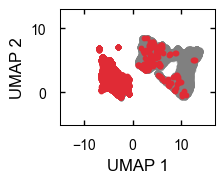

Output/fig1/matched_dimer_designed


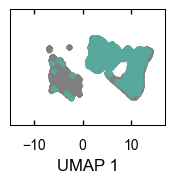

Output/fig1/matched_finches_designed


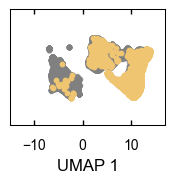

In [10]:
# First - joint embedding + defining some things like colors, sub-embeddings, etc.
from matplotlib.patches import Patch

base_size = 2

embedding_IDRome = embedding[:n_IDRome]
embedding_dimer = embedding[n_IDRome:n_IDRome + n_dimer]
embedding_finches = embedding[n_IDRome + n_dimer:]

colors = ['#e02b35', '#59a89c', '#f0c571'] # Red, Blue, Yellow
labels = ['IDRome', 'Dimer', 'Finches']

color_labels = np.concatenate([
    np.zeros(n_IDRome),
    1 * np.ones(n_dimer),
    2 * np.ones(n_finches),
])

### JOINT EMBEDDING PLOTTING - NOT USED RN ###
# fig, ax = plt.subplots(1,1, figsize = (base_size, base_size * 0.75))

# # plot combined embedding first
# make_nice_axis(ax)

# for i, (color, label) in enumerate(zip(colors, labels)):
#     mask = color_labels == i
#     ax.scatter(embedding[mask, 0], embedding[mask, 1], 
#                c = color, label = label, alpha = 0.5, s = 10)

# ax.scatter(embedding_IDRome[:, 0], embedding_IDRome[:, 1], c = colors[0], alpha = 0.5, s = 10)

# legend_elements = [Patch(facecolor = color, label = label, alpha = 1.0) for color, label in zip(colors, labels)]
# # ax.legend(handles = legend_elements, loc = 'upper left', frameon = False, fontsize = 12, bbox_to_anchor = (-0.01, 1))
# ax.set_xlabel('UMAP 1', fontsize = 12)
# ax.set_ylabel('UMAP 2', fontsize = 12)
# ax.set_yticks([0, 10])
# ax.set_xlim([-15, 30])
# ax.set_ylim([-10, 22])
# ax.set_xticks([-10, 0, 10, 20])



# fig_save = True
# fig_name = 'fig1/joint_UMAP'
# if fig_save:
#     print(save_dir + '/' + fig_name)
#     save_figure(fig, fig_file=save_dir + '/' + fig_name)
    
# plt.show()
### END OF JOINT EMBEDDING PLOTTING

# subpanel - plot the bioIDRs in color, rest in gray
fig, ax = plt.subplots(1,1, figsize = (base_size, base_size * 0.75))
make_nice_axis(ax)
ax.scatter(embedding_finches[: ,0], embedding_finches[: , 1], alpha = 0.5, s = 10, color = 'grey')
ax.scatter(embedding_dimer[: ,0], embedding_dimer[: , 1], alpha = 0.5, s = 10, color = 'grey')

ax.scatter(embedding_IDRome[:, 0], embedding_IDRome[:, 1], 
           c = colors[0], label = 'bioIDRs', alpha = 1.0, s = 10)


# legend_elements = [Patch(facecolor = colors[0], label = 'bioIDRs', alpha = 1.0)]
# ax.legend(handles = legend_elements, loc = 'upper left', frameon = False, fontsize = 12, bbox_to_anchor = (-0.01, 1))
ax.set_xlabel('UMAP 1', fontsize = 12)
ax.set_ylabel('UMAP 2', fontsize = 12)
ax.set_yticks([0, 10])
ax.set_xlim([-15, 17])
ax.set_ylim([-5, 13])
ax.set_xticks([-10, 0, 10])

fig_save = True
fig_name = 'fig1/matched_IDRome'
if fig_save:
    print(save_dir + '/' + fig_name)
    save_figure(fig, fig_file=save_dir + '/' + fig_name)
    
plt.show()

# subpanel - plot the dimer-designed sequences in color, rest in gray
fig, ax = plt.subplots(1,1, figsize = (base_size, base_size * 0.75))
make_nice_axis(ax)
ax.scatter(embedding_finches[: ,0], embedding_finches[: , 1], alpha = 0.5, s = 10, color = 'grey')
ax.scatter(embedding_IDRome[: ,0], embedding_IDRome[: , 1], alpha = 0.5, s = 10, color = 'grey')

ax.scatter(embedding_dimer[:, 0], embedding_dimer[:, 1], 
           c = colors[1], label = 'dimers', alpha = 1.0, s = 10)


# legend_elements = [Patch(facecolor = colors[0], label = 'bioIDRs', alpha = 1.0)]
# ax.legend(handles = legend_elements, loc = 'upper left', frameon = False, fontsize = 12, bbox_to_anchor = (-0.01, 1))
ax.set_xlabel('UMAP 1', fontsize = 12)
# ax.set_ylabel('UMAP 2', fontsize = 12)
ax.set_yticks([])
ax.set_xlim([-15, 17])
ax.set_ylim([-5, 13])
ax.set_xticks([-10, 0, 10])

fig_save = True
fig_name = 'fig1/matched_dimer_designed'
if fig_save:
    print(save_dir + '/' + fig_name)
    save_figure(fig, fig_file=save_dir + '/' + fig_name)

plt.show()

# subpanel - plot the FINCHES-designed sequences in color, rest in gray
fig, ax = plt.subplots(1,1, figsize = (base_size, base_size * 0.75))
make_nice_axis(ax)
ax.scatter(embedding_dimer[: ,0], embedding_dimer[: , 1], alpha = 0.5, s = 10, color = 'grey')
ax.scatter(embedding_IDRome[: ,0], embedding_IDRome[: , 1], alpha = 0.5, s = 10, color = 'grey')

ax.scatter(embedding_finches[:, 0], embedding_finches[:, 1], 
           c = colors[2], label = 'finches', alpha = 1.0, s = 10)


# legend_elements = [Patch(facecolor = colors[0], label = 'bioIDRs', alpha = 1.0)]
# ax.legend(handles = legend_elements, loc = 'upper left', frameon = False, fontsize = 12, bbox_to_anchor = (-0.01, 1))
ax.set_xlabel('UMAP 1', fontsize = 12)
# ax.set_ylabel('UMAP 2', fontsize = 12)
ax.set_yticks([])
ax.set_xlim([-15, 17])
ax.set_ylim([-5, 13])
ax.set_xticks([-10, 0, 10])

fig_save = True
fig_name = 'fig1/matched_finches_designed'
if fig_save:
    print(save_dir + '/' + fig_name)
    save_figure(fig, fig_file=save_dir + '/' + fig_name)

plt.show()


## Figure 2

### Figure 2b - salt sensors ###

In [11]:
path_to_fig2b_data = figures_data_dir + '/Fig2/data/salt_sensors.csv'
df = pd.read_csv(path_to_fig2b_data)

Output/fig2/fig_2b_contractor


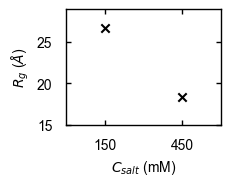

In [12]:
### contractor panel ###

import ast
fsize = 10
contractor_df = df[df['label'] == 'contractor']
contractor_rgs_str = df.loc[df["label"] == "contractor", "rgs"].iloc[0]
contractor_rgs = np.array(ast.literal_eval(contractor_rgs_str), dtype=float)

salts = [150, 450]
fig, ax = plt.subplots(figsize = (2, 2*0.75))
make_nice_axis(ax)
ax.scatter(salts, contractor_rgs, marker = 'x', color = 'black')
ax.set_xlabel('$C_{salt}$ (mM)', fontsize = fsize)
ax.set_ylabel('$R_g$ ($\AA$)', fontsize = fsize)
ax.set_xticks([150, 450])
ax.set_yticks([15, 20, 25])
ax.set_ylim([15, 29])
ax.set_xlim([0, 600])

ax.spines['right'].set_linewidth(1)
ax.spines['top'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)
ax.spines['bottom'].set_linewidth(1)
ax.tick_params(direction = 'in', labelsize = fsize)

fig_save = True
fig_name = 'fig2/fig_2b_contractor'
if fig_save:
    print(save_dir + '/' + fig_name)
    save_figure(fig, fig_file=save_dir + '/' + fig_name)

plt.show()


### Fig 2C - threshold sensing/designed response ###

In [13]:
path_to_2c_data = figures_data_dir + '/Fig2/data/threshold_sensing.csv'
df = pd.read_csv(path_to_2c_data)

Output/fig2/fig_2c_threshold_sensing


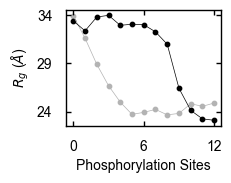

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import ast

fsize = 10

plt.rcParams['font.family'] = 'Arial'

# expander_rgs_str = df.loc[df["label"] == "expander", "rgs"].iloc[0]

early_step_df = df[df['label'] == 'early_step']
early_step_rg = np.array(ast.literal_eval(early_step_df['rgs'].iloc[0]), dtype=float)

late_step_df = df[df['label'] == 'late_step']
late_step_rg = np.array(ast.literal_eval(late_step_df['rgs'].iloc[0]), dtype=float)

fig, ax = plt.subplots(figsize = (2, 2*0.75))
make_nice_axis(ax)

# ax.plot(range(len(linear_rg)), linear_rg, linestyle = 'dashed', color = '#666666')
# ax.scatter(range(len(linear_rg)), linear_rg, color = '#666666', marker = '^', label = 'Linear')

ax.plot(range(len(early_step_rg)), early_step_rg, linestyle = 'solid', color = '#B3B3B3', linewidth = 0.5)
ax.scatter(range(len(early_step_rg)), early_step_rg, color = '#B3B3B3', marker = 'o', label = 'Early Step', s = 10)

ax.plot(range(len(late_step_rg)), late_step_rg, linestyle = 'solid', color = '#000000', linewidth = 0.5)
ax.scatter(range(len(late_step_rg)), late_step_rg, color = '#000000', marker = 'o', label = 'Late Step', s = 10)

ax.set_xlabel('Phosphorylation Sites', fontsize = fsize)
# ax.set_ylabel('$R_g$ / $R_g^{0}$', fontsize = 20)
ax.set_ylabel('$R_g$ ($\AA$)', fontsize = fsize)

# ax.legend(loc = 'upper right', frameon= False, fontsize = 20, markerscale = 2.5)

ax.tick_params(direction = 'in', labelsize = fsize)

ax.spines['right'].set_linewidth(1)
ax.spines['top'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)
ax.spines['bottom'].set_linewidth(1)
ax.set_yticks([24, 29, 34])
plt.xticks([0, 6, 12])

fig_save = True
fig_name = 'fig2/fig_2c_threshold_sensing'
if fig_save:
    print(save_dir + '/' + fig_name)
    save_figure(fig, fig_file=save_dir + '/' + fig_name)

plt.show()

### Fig 2D - bandpass filter/designed response ###

In [17]:
path_to_2d_data = figures_data_dir + '/Fig2/data/bandpass_data.csv'
df = pd.read_csv(path_to_2d_data)

Output/fig2/fig_2d_bandpass


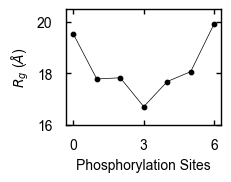

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fsize = 10

bandpass_rgs = df['rg']

fig, ax = plt.subplots(figsize = (2, 2*0.75))
make_nice_axis(ax)
ax.plot(range(len(bandpass_rgs)), bandpass_rgs, linestyle = 'solid', color = 'black', linewidth = 0.5)
ax.scatter(range(len(bandpass_rgs)), bandpass_rgs, color = 'black', marker = 'o', label = 'Bandpass', s = 10)

ax.set_xlabel('Phosphorylation Sites', fontsize = fsize)
ax.set_ylabel('$R_g$ ($\AA$)', fontsize = fsize)

# ax.legend(loc = 'upper right', frameon= False, fontsize = 20, markerscale = 2.5)

ax.tick_params(direction = 'in', labelsize = fsize)

ax.spines['right'].set_linewidth(1)
ax.spines['top'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)
ax.spines['bottom'].set_linewidth(1)

ax.set_yticks([16, 18, 20])
ax.set_ylim([16, 20.5])
ax.set_xticks([0, 3, 6])
ax.tick_params(axis = 'both', direction = 'in', labelsize = fsize)

fig_save = True
fig_name = 'fig2/fig_2d_bandpass'
if fig_save:
    print(save_dir + '/' + fig_name)
    save_figure(fig, fig_file=save_dir + '/' + fig_name)

plt.show()

### Fig 2E - multi-dimensional sensors ###

In [19]:
path_to_2e_data = figures_data_dir + '/Fig2/data/2d_sensors.csv'
df = pd.read_csv(path_to_2e_data)

Output/fig2/fig_2e_phos_methyl_XOR


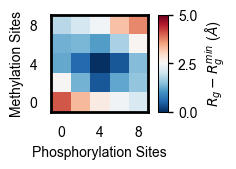

In [20]:
# 2d phos - methyl XOR gate
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

fsize = 10

def parse_rgs(txt: str) -> np.ndarray:
    rows = []
    for line in txt.strip().splitlines():
        line = line.strip().strip("[]")
        if line:
            rows.append([float(x) for x in line.split()])

    return np.array(rows)

## make same plot as above but with different data/reading in from csv

methyl_levels = ['0', '2', '4', '6', '8']
# phosp_levels = [0, 2, 4, 6, 8]
phosp_labels = ['0', '2', '4', '6', '8']

data = np.zeros((len(methyl_levels), len(phosp_labels)))

for i, row in df.iterrows():
    label = row['conditions']
    # print(type(tgt))
    if label == 'phos_methyl':
        # print(row['rgs'])
        data = parse_rgs(row['rgs'])


plt.rcParams["font.family"] = "Arial"

# --- dimensions in inches ---
plot_width = .9705
plot_height = .9705
left_margin = 0.5
bottom_margin = 0.5
right_margin = 0.3
top_margin = 0.3
cbar_width = 0.10
cbar_pad = 0.10

fig_width = left_margin + plot_width + cbar_pad + cbar_width + right_margin
fig_height = bottom_margin + plot_height + top_margin

fig = plt.figure(figsize=(fig_width, fig_height))

# main axes sized exactly (plot_width x plot_height inches)
ax = fig.add_axes([
    left_margin / fig_width,
    bottom_margin / fig_height,
    plot_width / fig_width,
    plot_height / fig_height,
])

make_nice_axis(ax)
data_transposed = data
h, w = data_transposed.shape

data_transposed = data_transposed - np.min(data_transposed)

im = ax.imshow(
    data_transposed,
    cmap="RdBu_r",
    vmin=0, vmax=5,
    interpolation="none",
    resample=False,
    origin="lower",
    extent=(-0.5, w - 0.5, -0.5, h - 0.5),
)
ax.set_xlim(-0.5, w - 0.5)
ax.set_ylim(-0.5, h - 0.5)
ax.set_aspect("equal")
ax.grid(False)

methyl_concentrations = ["0", "", "4", "", "8"]
phosp_concentrations = ["0", "", "4", "", "8"]
ax.set_xticks(range(w))
ax.set_yticks(range(h))
ax.set_yticklabels(methyl_concentrations, fontsize=fsize)
ax.set_xticklabels(phosp_concentrations, fontsize=fsize)
ax.tick_params(axis="both", which="both", length=0)

ax.spines['right'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)

ax.set_ylabel("Methylation Sites", fontsize=fsize)
ax.set_xlabel("Phosphorylation Sites", fontsize=fsize)

# dedicated colorbar axis with fixed inch size matching the plot height
cax = fig.add_axes([
    (left_margin + plot_width + cbar_pad) / fig_width,
    bottom_margin / fig_height,
    cbar_width / fig_width,
    plot_height / fig_height,
])
cbar = plt.colorbar(im, cax=cax)
cbar.set_label(r"$R_g - R_g^{min}$ ($\AA$)", fontsize=fsize)
cbar.set_ticks([0, 2.5, 5])
cbar.ax.tick_params(labelsize=fsize)

fig_save = True
fig_name = 'fig2/fig_2e_phos_methyl_XOR'
if fig_save:
    print(save_dir + '/' + fig_name)
    save_figure(fig, fig_file=save_dir + '/' + fig_name)

plt.show()

Output/fig2/fig_2e_salt_phos_OR


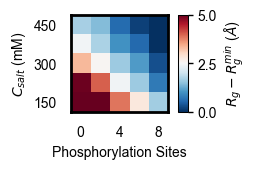

In [21]:
# 2d phos - methyl XOR gate
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

fsize = 10

def parse_rgs(txt: str) -> np.ndarray:
    rows = []
    for line in txt.strip().splitlines():
        line = line.strip().strip("[]")
        if line:
            rows.append([float(x) for x in line.split()])

    return np.array(rows)

## make same plot as above but with different data/reading in from csv

methyl_levels = ['0', '2', '4', '6', '8']
# phosp_levels = [0, 2, 4, 6, 8]
phosp_labels = ['0', '2', '4', '6', '8']

data = np.zeros((len(methyl_levels), len(phosp_labels)))

for i, row in df.iterrows():
    label = row['conditions']
    # print(type(tgt))
    if label == 'salt_phosp':
        # print(row['rgs'])
        data = parse_rgs(row['rgs'])


plt.rcParams["font.family"] = "Arial"

# --- dimensions in inches ---
plot_width = .9705
plot_height = .9705
left_margin = 0.5
bottom_margin = 0.5
right_margin = 0.3
top_margin = 0.3
cbar_width = 0.10
cbar_pad = 0.10

fig_width = left_margin + plot_width + cbar_pad + cbar_width + right_margin
fig_height = bottom_margin + plot_height + top_margin

fig = plt.figure(figsize=(fig_width, fig_height))

# main axes sized exactly (plot_width x plot_height inches)
ax = fig.add_axes([
    left_margin / fig_width,
    bottom_margin / fig_height,
    plot_width / fig_width,
    plot_height / fig_height,
])

make_nice_axis(ax)
data_transposed = data
h, w = data_transposed.shape

data_transposed = data_transposed - np.min(data_transposed)

im = ax.imshow(
    data_transposed,
    cmap="RdBu_r",
    vmin=0, vmax=5,
    interpolation="none",
    resample=False,
    origin="lower",
    extent=(-0.5, w - 0.5, -0.5, h - 0.5),
)
ax.set_xlim(-0.5, w - 0.5)
ax.set_ylim(-0.5, h - 0.5)
ax.set_aspect("equal")
ax.grid(False)

salt_concentrations = ["150", '', "300", '', "450"]
phosp_concentrations = ["0", "", "4", "", "8"]
ax.set_xticks(range(w))
ax.set_yticks(range(h))
ax.set_yticklabels(salt_concentrations, fontsize=fsize)
ax.set_xticklabels(phosp_concentrations, fontsize=fsize)
ax.tick_params(axis="both", which="both", length=0)

ax.spines['right'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)

ax.set_ylabel("$C_{salt}$ (mM)", fontsize=fsize)
ax.set_xlabel("Phosphorylation Sites", fontsize=fsize)

# dedicated colorbar axis with fixed inch size matching the plot height
cax = fig.add_axes([
    (left_margin + plot_width + cbar_pad) / fig_width,
    bottom_margin / fig_height,
    cbar_width / fig_width,
    plot_height / fig_height,
])
cbar = plt.colorbar(im, cax=cax)
cbar.set_label(r"$R_g - R_g^{min}$ ($\AA$)", fontsize=fsize)
cbar.set_ticks([0, 2.5, 5])
cbar.ax.tick_params(labelsize=fsize)

fig_save = True
fig_name = 'fig2/fig_2e_salt_phos_OR'
if fig_save:
    print(save_dir + '/' + fig_name)
    save_figure(fig, fig_file=save_dir + '/' + fig_name)

plt.show()

Output/fig2/fig_2e_methyl_phos_NAND


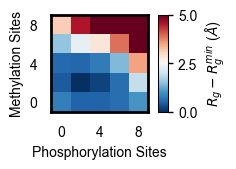

In [22]:
# 2d phos - methyl XOR gate
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

fsize = 10

def parse_rgs(txt: str) -> np.ndarray:
    rows = []
    for line in txt.strip().splitlines():
        line = line.strip().strip("[]")
        if line:
            rows.append([float(x) for x in line.split()])

    return np.array(rows)

## make same plot as above but with different data/reading in from csv

methyl_levels = ['0', '2', '4', '6', '8']
# phosp_levels = [0, 2, 4, 6, 8]
phosp_labels = ['0', '2', '4', '6', '8']

data = np.zeros((len(methyl_levels), len(phosp_labels)))

for i, row in df.iterrows():
    label = row['conditions']
    # print(type(tgt))
    if label == 'methyl_phos':
        # print(row['rgs'])
        data = parse_rgs(row['rgs'])


plt.rcParams["font.family"] = "Arial"

# --- dimensions in inches ---
plot_width = .9705
plot_height = .9705
left_margin = 0.5
bottom_margin = 0.5
right_margin = 0.3
top_margin = 0.3
cbar_width = 0.10
cbar_pad = 0.10

fig_width = left_margin + plot_width + cbar_pad + cbar_width + right_margin
fig_height = bottom_margin + plot_height + top_margin

fig = plt.figure(figsize=(fig_width, fig_height))

# main axes sized exactly (plot_width x plot_height inches)
ax = fig.add_axes([
    left_margin / fig_width,
    bottom_margin / fig_height,
    plot_width / fig_width,
    plot_height / fig_height,
])

make_nice_axis(ax)
data_transposed = data
h, w = data_transposed.shape

data_transposed = data_transposed - np.min(data_transposed)

im = ax.imshow(
    data_transposed,
    cmap="RdBu_r",
    vmin=0, vmax=5,
    interpolation="none",
    resample=False,
    origin="lower",
    extent=(-0.5, w - 0.5, -0.5, h - 0.5),
)
ax.set_xlim(-0.5, w - 0.5)
ax.set_ylim(-0.5, h - 0.5)
ax.set_aspect("equal")
ax.grid(False)

methyl_concentrations = ["0", "", "4", "", "8"]
phosp_concentrations = ["0", "", "4", "", "8"]
ax.set_xticks(range(w))
ax.set_yticks(range(h))
ax.set_yticklabels(methyl_concentrations, fontsize=fsize)
ax.set_xticklabels(phosp_concentrations, fontsize=fsize)
ax.tick_params(axis="both", which="both", length=0)

ax.spines['right'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)

ax.set_ylabel("Methylation Sites", fontsize=fsize)
ax.set_xlabel("Phosphorylation Sites", fontsize=fsize)

# dedicated colorbar axis with fixed inch size matching the plot height
cax = fig.add_axes([
    (left_margin + plot_width + cbar_pad) / fig_width,
    bottom_margin / fig_height,
    cbar_width / fig_width,
    plot_height / fig_height,
])
cbar = plt.colorbar(im, cax=cax)
cbar.set_label(r"$R_g - R_g^{min}$ ($\AA$)", fontsize=fsize)
cbar.set_ticks([0, 2.5, 5])
cbar.ax.tick_params(labelsize=fsize)

fig_save = True
fig_name = 'fig2/fig_2e_methyl_phos_NAND'
if fig_save:
    print(save_dir + '/' + fig_name)
    save_figure(fig, fig_file=save_dir + '/' + fig_name)

plt.show()

### Fig 3B ###

In [23]:
path_to_fig3b_data = figures_data_dir + '/Fig3/data/'
fig3b_layered_1us_data = pd.read_csv(path_to_fig3b_data + 'fig3B_layered_random_density_data_1us.csv')
fig3b_2droplet_1us_data = pd.read_csv(path_to_fig3b_data + 'fig3b_four_idp_random_density_data_1us.csv')
fig3brna_1us_data = pd.read_csv(path_to_fig3b_data + '2idp_60rna_density_data_1us.csv')
fig3brna_protein_data = pd.read_csv(path_to_fig3b_data + 'fig3Brna_two_idp_density_data_1us.csv')

Output/fig3/fig3b_layered_random_1us


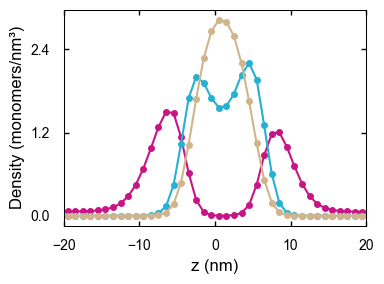

In [24]:
idp1 = fig3b_layered_1us_data['layered_idp1_intensity'].values
idp2 = fig3b_layered_1us_data['layered_idp2_intensity'].values
idp3 = fig3b_layered_1us_data['layered_idp3_intensity'].values
z = fig3b_layered_1us_data["z"].values
fig, ax = plt.subplots(1, 1, figsize=(4, 3))
make_nice_axis(ax) 

ax.plot(z, idp1, "o-", color="#C71585", linewidth=1.5, markersize=4, label="IDP1")
ax.plot(z, idp2, "o-", color='#26B0D2', linewidth=1.5, markersize=4, label="IDP2")
ax.plot(z, idp3, "o-", color='#D2B48C', linewidth=1.5, markersize=4, label="IDP3")
ax.set_yticks([0.0, 1.2, 2.4])
ax.set_xlim(-20, 20)
ax.set_xlabel("z (nm)")
ax.set_ylabel("Density (monomers/nm³)")

plt.tight_layout()
fig_save = True
fig_name = "fig3/fig3b_layered_random_1us"
if fig_save:
    print(save_dir + "/" + fig_name)
    save_figure(fig, fig_file=save_dir + "/" + fig_name)
plt.show()

Output/fig3/fig3b_2droplet_4IDP_random_1us


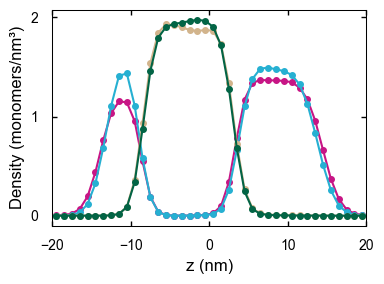

In [25]:
idp1 = fig3b_2droplet_1us_data["3a_idp1_intensity"].values
idp2 = fig3b_2droplet_1us_data["3a_idp2_intensity"].values
idp3 = fig3b_2droplet_1us_data["3a_idp3_intensity"].values
idp4 = fig3b_2droplet_1us_data["3a_idp4_intensity"].values
z = fig3b_2droplet_1us_data["z"].values
fig, ax = plt.subplots(1, 1, figsize=(4, 3))
make_nice_axis(ax) 

ax.plot(z, idp1, "o-", color='#C71585', linewidth=1.5, markersize=4, label="IDP1")
ax.plot(z, idp2, "o-", color='#26B0D2', linewidth=1.5, markersize=4, label="IDP2")
ax.plot(z, idp3, "o-", color='#D2B48C', linewidth=1.5, markersize=4, label="IDP3")
ax.plot(z, idp4, "o-", color='#026445', linewidth=1.5, markersize=4, label="IDP4")
ax.set_yticks([0.0, 1.0, 2.0])
ax.set_xlim(-20, 20)
ax.set_xlabel("z (nm)")
ax.set_ylabel("Density (monomers/nm³)")


plt.tight_layout()
fig_save = True
fig_name = "fig3/fig3b_2droplet_4IDP_random_1us"
if fig_save:
    print(save_dir + "/" + fig_name)
    save_figure(fig, fig_file=save_dir + "/" + fig_name)
plt.show()

Output/fig3/fig3b_1droplet_4IDP_random_1us


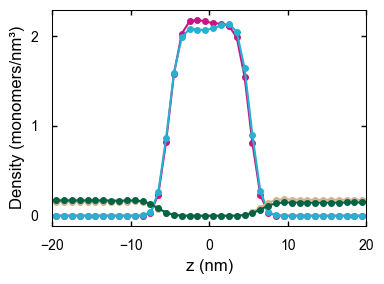

In [26]:
idp1 = fig3b_2droplet_1us_data["3b_idp1_intensity"].values
idp2 = fig3b_2droplet_1us_data["3b_idp2_intensity"].values
idp3 = fig3b_2droplet_1us_data["3b_idp3_intensity"].values
idp4 = fig3b_2droplet_1us_data["3b_idp4_intensity"].values
z = fig3b_2droplet_1us_data["z"].values
fig, ax = plt.subplots(1, 1, figsize=(4, 3))
make_nice_axis(ax) 

ax.plot(z, idp1, "o-", color='#C71585', linewidth=1.5, markersize=4, label="IDP1")
ax.plot(z, idp2, "o-", color='#26B0D2', linewidth=1.5, markersize=4, label="IDP2")
ax.plot(z, idp3, "o-", color='#D2B48C', linewidth=1.5, markersize=4, label="IDP3")
ax.plot(z, idp4, "o-", color='#026445', linewidth=1.5, markersize=4, label="IDP4")
ax.set_yticks([0.0, 1.0, 2.0])
ax.set_xlim(-20, 20)
ax.set_xlabel("z (nm)")
ax.set_ylabel("Density (monomers/nm³)")


plt.tight_layout()
fig_save = True
fig_name = "fig3/fig3b_1droplet_4IDP_random_1us"
if fig_save:
    print(save_dir + "/" + fig_name)
    save_figure(fig, fig_file=save_dir + "/" + fig_name)
plt.show()

Output/fig3/fig3b_rna_2idp_random_1us


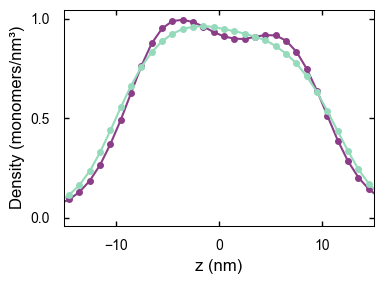

In [27]:
idp1 = fig3brna_protein_data['idp1_intensity'].values
idp2 = fig3brna_protein_data['idp2_intensity'].values
z = fig3brna_protein_data["z"].values
fig, ax = plt.subplots(1, 1, figsize=(4, 3))
make_nice_axis(ax) 

ax.plot(z, idp1, "o-", color="#8B3D88", linewidth=1.5, markersize=4, label="IDP1")
ax.plot(z, idp2, "o-", color='#95DABB', linewidth=1.5, markersize=4, label="IDP2")
ax.set_yticks([0.0, 0.5,1.0])
ax.set_xticks([-10, 0, 10])
ax.set_xlim(-15, 15)
ax.set_xlabel("z (nm)")
ax.set_ylabel("Density (monomers/nm³)")

plt.tight_layout()
fig_save = True
fig_name = "fig3/fig3b_rna_2idp_random_1us"
if fig_save:
    print(save_dir + "/" + fig_name)
    save_figure(fig, fig_file=save_dir + "/" + fig_name)

Output/fig3/fig3b_2idp_60rna_random_1us


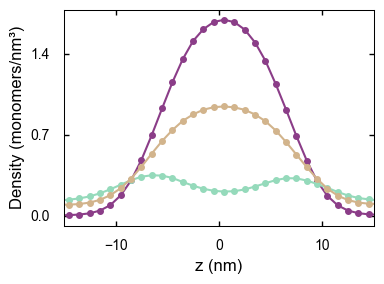

In [28]:
idp1 = fig3brna_1us_data['idp1_intensity'].values
idp2 = fig3brna_1us_data['idp2_intensity'].values
rna = fig3brna_1us_data['rna_intensity'].values
z = fig3brna_1us_data["z"].values
fig, ax = plt.subplots(1, 1, figsize=(4, 3))
make_nice_axis(ax) 

ax.plot(z, idp1, "o-", color="#8B3D88", linewidth=1.5, markersize=4, label="IDP1")
ax.plot(z, idp2, "o-", color='#95DABB', linewidth=1.5, markersize=4, label="IDP2")
ax.plot(z, rna, "o-", color='#D2B48C', linewidth=1.5, markersize=4, label="RNA")
ax.set_yticks([0.0, 0.7, 1.4])
ax.set_xticks([-10, 0, 10])
ax.set_xlim(-15, 15)
ax.set_xlabel("z (nm)")
ax.set_ylabel("Density (monomers/nm³)")

plt.tight_layout()
fig_save = True
fig_name = "fig3/fig3b_2idp_60rna_random_1us"
if fig_save:
    print(save_dir + "/" + fig_name)
    save_figure(fig, fig_file=save_dir + "/" + fig_name)
plt.show()

### Fig 4B ###

In [12]:
path_to_fig4b_data = figures_data_dir + '/Fig4/data/'
fig4b_data = pd.read_csv(path_to_fig4b_data + 'fig4b.csv')

Output/fig4/fig4b


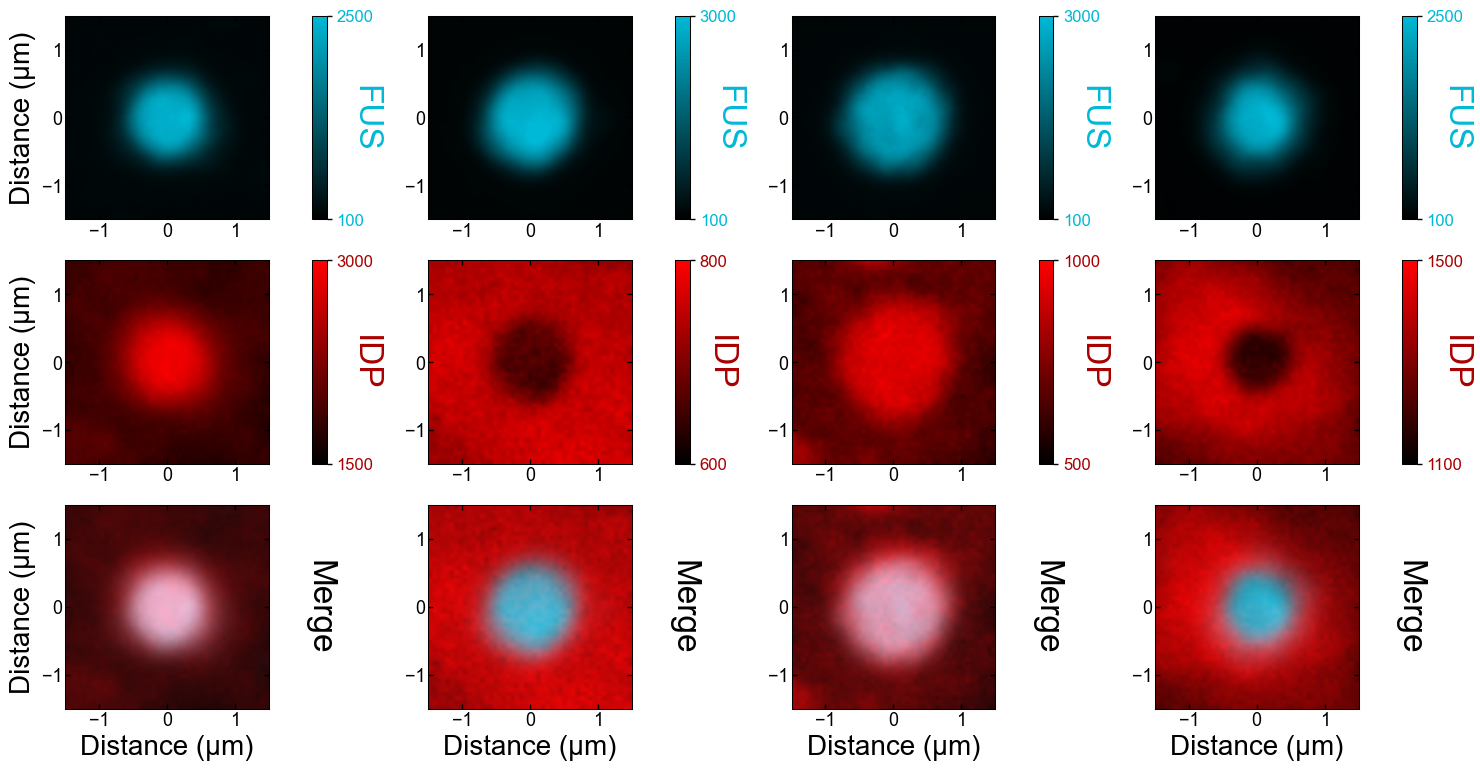

In [13]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.colors as mcolors
df = fig4b_data

# Define order: client_bio, excluder_bio, client_denovo, excluder_denovo
categories_order = ['client_bio', 'excluder_bio', 'client_denovo', 'excluder_denovo']

# Reconstruct images for each category
category_images = {}

for category in categories_order:
    cat_data = df[df['category'] == category]
    
    if len(cat_data) == 0:
        continue
    
    # Get image dimensions from data
    max_x = int(cat_data['x_pixel'].max()) + 1
    max_y = int(cat_data['y_pixel'].max()) + 1
    
    # Reconstruct FUS, Protein, and RGB images
    fus_mean = np.zeros((max_y, max_x), dtype=np.float32)
    protein_mean = np.zeros((max_y, max_x), dtype=np.float32)
    rgb = np.zeros((max_y, max_x, 3), dtype=np.float32)
    
    for _, row in cat_data.iterrows():
        y = int(row['y_pixel'])
        x = int(row['x_pixel'])
        fus_mean[y, x] = row['fus_intensity'] if pd.notna(row['fus_intensity']) else 0
        protein_mean[y, x] = row['protein_intensity'] if pd.notna(row['protein_intensity']) else 0
        rgb[y, x, 0] = row['rgb_red']
        rgb[y, x, 1] = row['rgb_green']
        rgb[y, x, 2] = row['rgb_blue']
    
    # Get metadata
    n_blobs = int(cat_data['n_blobs'].iloc[0])
    box_size_um = float(cat_data['box_size_um'].iloc[0])
    fus_min = float(cat_data['fus_min'].iloc[0])
    fus_max = float(cat_data['fus_max'].iloc[0])
    protein_min = float(cat_data['protein_min'].iloc[0])
    protein_max = float(cat_data['protein_max'].iloc[0])
    
    # Get colorbar metadata
    fus_colorbar_hex = cat_data['fus_colorbar_hex'].iloc[0]
    protein_colorbar_hex = cat_data['protein_colorbar_hex'].iloc[0]
    fus_colorbar_label = cat_data['fus_colorbar_label'].iloc[0]
    protein_colorbar_label = cat_data['protein_colorbar_label'].iloc[0]
    
    half_box_um = box_size_um / 2.0
    extent = [-half_box_um, half_box_um, -half_box_um, half_box_um]
    
    category_images[category] = {
        'fus_mean': fus_mean,
        'protein_mean': protein_mean,
        'rgb': rgb,
        'n_blobs': n_blobs,
        'extent': extent,
        'fus_min': fus_min,
        'fus_max': fus_max,
        'protein_min': protein_min,
        'protein_max': protein_max,
        'fus_colorbar_hex': fus_colorbar_hex,
        'protein_colorbar_hex': protein_colorbar_hex,
        'fus_colorbar_label': fus_colorbar_label,
        'protein_colorbar_label': protein_colorbar_label,
    }


fig = plt.figure(figsize=(18, 9))
gs = fig.add_gridspec(3, 11, 
                      width_ratios=[1, 0.05, 0.2, 1, 0.05, 0.2, 1, 0.05, 0.2, 1, 0.05], 
                      hspace=0.2, wspace=0.0)  

half_box_um = box_size_um / 2.0

col_positions = [0, 3, 6, 9]  
cbar_positions = [1, 4, 7, 10]  

# ===== ROW 1: FUS Channel =====

FUS_RANGES = {
    'client_bio':      {'vmin': 100, 'vmax': 2500, 'ticks': [100, 2500]},
    'excluder_bio':    {'vmin':  100, 'vmax': 3000, 'ticks': [ 100, 3000]},
    'client_denovo':   {'vmin':  100, 'vmax': 3000, 'ticks': [ 100, 3000]},
    'excluder_denovo': {'vmin': 100, 'vmax': 2500, 'ticks': [100, 2500]},
}

for idx, category in enumerate(categories_order):
    if category in category_images:
        # Image subplot
        ax = fig.add_subplot(gs[0, col_positions[idx]])
        make_nice_axis(ax) 
        data = category_images[category]
        
        # Create blue colormap
        fus_hex = '#00b9d7'
        fus_rgb = np.array(mcolors.hex2color(fus_hex))

        colors_cyan = [(0, 0, 0), tuple(fus_rgb * 0.5), tuple(fus_rgb)]
        cmap_cyan   = LinearSegmentedColormap.from_list('cyan', colors_cyan, N=256)

        
        f_range = FUS_RANGES[category]
        # Display FUS channel
        im = ax.imshow(data['fus_mean'], origin='upper', aspect='equal', 
                      interpolation='bilinear', extent=data['extent'], 
                      cmap=cmap_cyan, vmin=f_range['vmin'], vmax=f_range['vmax'])
        
        # Add title with number of blobs
        # ax.set_title(f'{category.upper()}\n\nn={data["n_blobs"]}')
        
        # Add axis labels
        if idx == 0:  
            ax.set_ylabel('Distance (μm)',fontsize=20)
        ax.tick_params(labelsize=13, pad=2)
        # Set axis limits
        ax.set_xlim(-half_box_um, half_box_um)
        ax.set_ylim(-half_box_um, half_box_um)
        
        
        # Colorbar subplot for this condition (right next to image)
        ax_cbar = fig.add_subplot(gs[0, cbar_positions[idx]])
        
        # Create colorbar directly from the image
        fus_ticks = [100, 3000]
        cbar = plt.colorbar(im, cax=ax_cbar, orientation='vertical',
                    ticks=f_range['ticks'])                                  
        cbar.ax.set_yticklabels([f'{t:.0f}' for t in f_range['ticks']])
        cbar.ax.tick_params(labelcolor='#00b9d7')
        cbar.set_label('FUS', 
                       color='#00b9d7', rotation=270, labelpad=5,fontsize=24)

# ===== ROW 2: Protein Channel =====

PROTEIN_RANGES = {
    'client_bio':      {'vmin': 1500, 'vmax': 3000, 'ticks': [1500, 3000]},
    'excluder_bio':    {'vmin':  600, 'vmax': 800, 'ticks': [ 600, 800]},
    'client_denovo':   {'vmin':  500, 'vmax': 1000, 'ticks': [ 500, 1000]},
    'excluder_denovo': {'vmin': 1100, 'vmax': 1500, 'ticks': [1100, 1500]},
}


for idx, category in enumerate(categories_order):
    if category in category_images:
        # Image subplot
        ax = fig.add_subplot(gs[1, col_positions[idx]])
        make_nice_axis(ax) 
        data = category_images[category]
        
        # Create red colormap
        colors_red = [(0, 0, 0), (0.5, 0, 0), (1, 0, 0)]
        cmap_red = LinearSegmentedColormap.from_list('red', colors_red, N=100)
        
        p_range = PROTEIN_RANGES[category]

        # Display Protein channel
        im = ax.imshow(data['protein_mean'], origin='upper', aspect='equal', 
                      interpolation='bilinear', extent=data['extent'], 
                      cmap=cmap_red, vmin=p_range['vmin'], vmax=p_range['vmax'])
        
        # Add axis labels
        if idx == 0:  
            ax.set_ylabel('Distance (μm)',fontsize=20)
        ax.tick_params(labelsize=13, pad=2)
        # Set axis limits
        ax.set_xlim(-half_box_um, half_box_um)
        ax.set_ylim(-half_box_um, half_box_um)
        
        # Colorbar subplot for this condition
        ax_cbar = fig.add_subplot(gs[1, cbar_positions[idx]])
        
        # Create colorbar directly from the image
        cbar    = plt.colorbar(im, cax=ax_cbar, orientation='vertical',
                           ticks=p_range['ticks'])  
        cbar.ax.set_yticklabels([f'{t:.0f}' for t in p_range['ticks']])
        cbar.ax.tick_params(labelcolor=data['protein_colorbar_hex'])
        cbar.set_label('IDP', 
                       color=data['protein_colorbar_hex'], rotation=270, labelpad=5,fontsize=24)

# ===== ROW 3: RGB Composite =====

# ===== ROW 3: Merge (cyan FUS + red Protein) =====
FUS_HEX = '#00b9d7'
fus_rgb  = np.array(mcolors.hex2color(FUS_HEX))   # (0, 0.725, 0.843)

for idx, category in enumerate(categories_order):
    if category not in category_images:
        continue

    ax   = fig.add_subplot(gs[2, col_positions[idx]])
    make_nice_axis(ax)
    data = category_images[category]

    f_range = FUS_RANGES[category]
    p_range = PROTEIN_RANGES[category]

    # Normalize to [0, 1] using the same display ranges as rows 1 & 2
    fus_norm     = np.clip((data['fus_mean']     - f_range['vmin']) / (f_range['vmax'] - f_range['vmin']), 0, 1)
    protein_norm = np.clip((data['protein_mean'] - p_range['vmin']) / (p_range['vmax'] - p_range['vmin']), 0, 1)

    # Cyan (#00b9d7) FUS  +  Red (1,0,0) Protein  →  additive RGB merge
    rgb_new         = np.zeros((*fus_norm.shape, 3), dtype=np.float32)
    rgb_new[..., 0] = np.clip(protein_norm + fus_norm * fus_rgb[0], 0, 1)  # R
    rgb_new[..., 1] = np.clip(fus_norm     * fus_rgb[1],             0, 1)  # G
    rgb_new[..., 2] = np.clip(fus_norm     * fus_rgb[2],             0, 1)  # B

    ax.imshow(rgb_new, origin='upper', aspect='equal',
              interpolation='bilinear', extent=data['extent'])
    
        # Add axis labels
    ax.set_xlabel('Distance (μm)',fontsize=20)
    if idx == 0:  # Leftmost column
        ax.set_ylabel('Distance (μm)',fontsize=20)
    ax.tick_params(labelsize=13, pad=2)
    # Set axis limits
    ax.set_xlim(-half_box_um, half_box_um)
    ax.set_ylim(-half_box_um, half_box_um)
        
        # Empty subplot for alignment (no colorbar needed for RGB)
    ax_empty = fig.add_subplot(gs[2, cbar_positions[idx]])
    ax_empty.axis('off')
    ax_empty.text(0.5, 0.5, 'Merge', rotation=270,
                  va='center', ha='center', fontsize=24,
                  transform=ax_empty.transAxes)

fig_save = True
fig_name = 'fig4/fig4b'
if fig_save:
    print(save_dir + '/' + fig_name)
    save_figure(fig, fig_file=save_dir+'/'+fig_name)
plt.show()
